In [43]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import ttest_ind, levene
from statsmodels.stats.proportion import proportions_ztest

import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [44]:
file_path = 'cookie_cats.csv'
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

### Data Cleaning and Data Preprocessing

In [45]:
df = pd.read_csv(file_path)

In [46]:
print("Total Rows: ",df.shape[0])
print("Total Columns: ",df.shape[1])

Total Rows:  90189
Total Columns:  5


In [47]:
print("Total Null Values:-\n")
display(df.isnull().sum())

df.dropna(inplace=True)

Total Null Values:-



userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [48]:
print("Total Duplicates: ",df.duplicated().sum())

if df.duplicated().sum()>0:
    df.drop_duplicates(subset='userid',inplace=True)

Total Duplicates:  0


In [49]:
# Veriying DataTypes of the Columns
print("Data Types and non-null counts:-\n")
print(df.info())

Data Types and non-null counts:-

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB
None


In [50]:
print("Summary Statistics of the dataset:- \n")
print(df['sum_gamerounds'].describe())

Summary Statistics of the dataset:- 

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64


### Column Description

- `userid`&#8594; Unique id asigned to each user.
- `version [CATEGORICAL]`&#8594; Version of the game the player is using.
- `sum_gamerrounds [NUMERICAL]`&#8594; total number of game rounds played by each user during testing period.
- `retention_1 [CATEGORICAL]`&#8594; This column shows whether a player returned to the game one day after installation.
- `retention_7 [CATEGORICAL]`&#8594; This column shows whether a player returned to the game seven day after installation.



In [51]:
print("Column names: ",df.columns)

Column names:  Index(['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7'], dtype='object')


### EDA

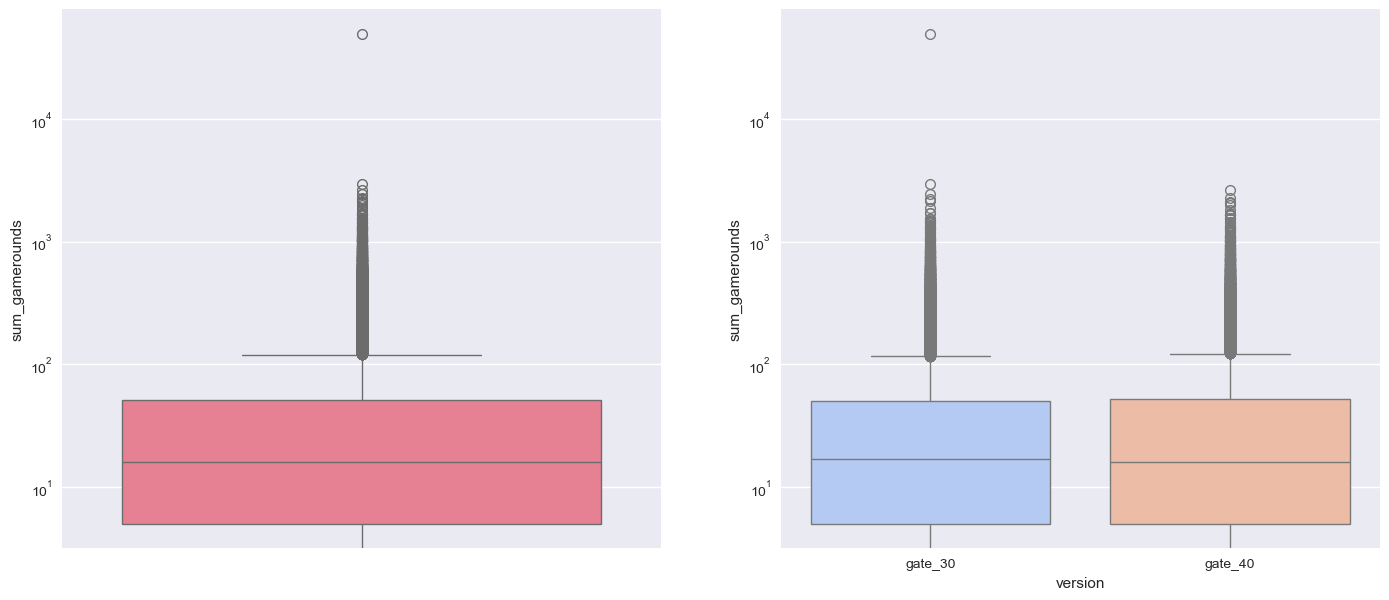

In [52]:
fig,ax = plt.subplots(1,2,figsize=(17,7))
sns.boxplot(data=df,y='sum_gamerounds',ax=ax[0])
ax[0].set_yscale('log')

sns.boxplot(data=df,x='version',y='sum_gamerounds',hue='version',ax=ax[1],palette='coolwarm')
ax[1].set_yscale('log')
plt.show()

In [53]:
version = df['version'].value_counts(normalize=True).reset_index()
version['proportion'] = version['proportion'].mul(100).round(2)
display(version)

,version,proportion
0,gate_40,50.44
1,gate_30,49.56


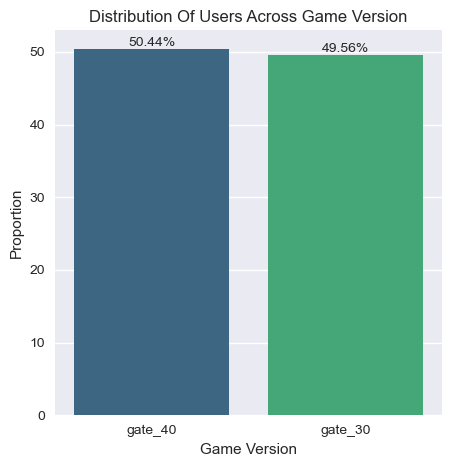

In [54]:
fig,ax = plt.subplots(1,1,figsize=(5,5))
sns.barplot(data = version,x='version',y='proportion',hue='version',palette='viridis')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}%',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom')
ax.set_title('Distribution Of Users Across Game Version')
ax.set_xlabel('Game Version')
ax.set_ylabel('Proportion')
plt.show()

In [55]:
retention_1 = df['retention_1'].value_counts(normalize=True).reset_index()
retention_1['proportion'] = retention_1['proportion'].mul(100).round(2)
retention_1['retention_1']=retention_1['retention_1'].apply(lambda x: 'Returned' if x==True else 'Not Returned')

retention_7 = df['retention_7'].value_counts(normalize=True).reset_index()
retention_7['proportion'] = retention_7['proportion'].mul(100).round(2)
retention_7['retention_7']=retention_7['retention_7'].apply(lambda x: 'Returned' if x==True else 'Not Returned')



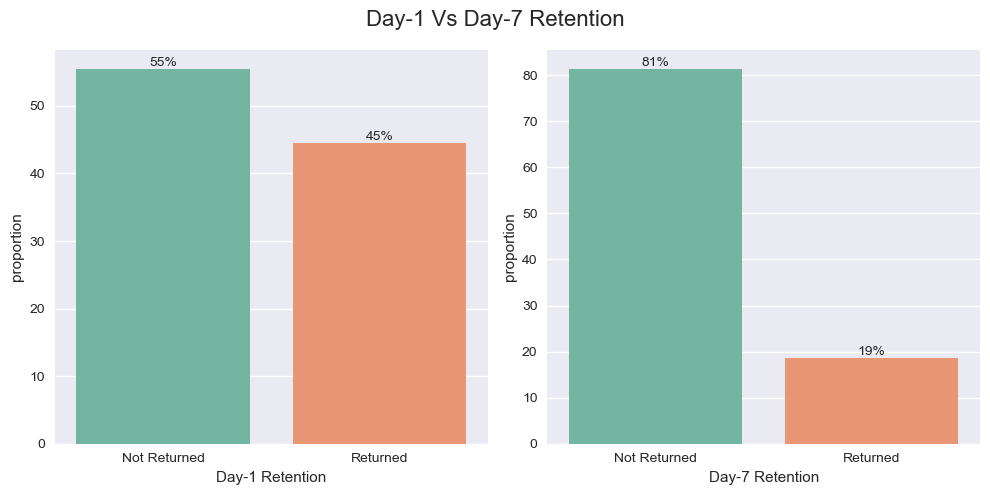

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle('Day-1 Vs Day-7 Retention', fontsize=16)
sns.barplot(data=retention_1, x='retention_1', y='proportion', hue='retention_1', palette='Set2', ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.0f}%', 
                   (p.get_x() + p.get_width() / 2, p.get_height()), 
                   ha='center', va='bottom')
ax[0].set_xlabel('Day-1 Retention')
ax[1].set_xlabel('Day-7 Retention')

sns.barplot(data=retention_7, x='retention_7', y='proportion', hue='retention_7', palette='Set2', ax=ax[1])
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.0f}%', 
                   (p.get_x() + p.get_width() / 2, p.get_height()), 
                   ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [57]:
# Users returning after 1 day per Version
ver_ret_1 = df.groupby(['version'])['retention_1'].value_counts(normalize=True).reset_index()
ver_ret_1['proportion'] = ver_ret_1['proportion'].mul(100).round(2)
display(ver_ret_1)

,version,retention_1,proportion
0,gate_30,False,55.18
1,gate_30,True,44.82
2,gate_40,False,55.77
3,gate_40,True,44.23


In [58]:
# Users returning after 7 day per Version

ver_ret_7 = df.groupby(['version'])['retention_7'].value_counts(normalize=True).reset_index()
ver_ret_7['proportion'] = ver_ret_7['proportion'].mul(100).round(2)
display(ver_ret_7)

,version,retention_7,proportion
0,gate_30,False,80.98
1,gate_30,True,19.02
2,gate_40,False,81.80
3,gate_40,True,18.20


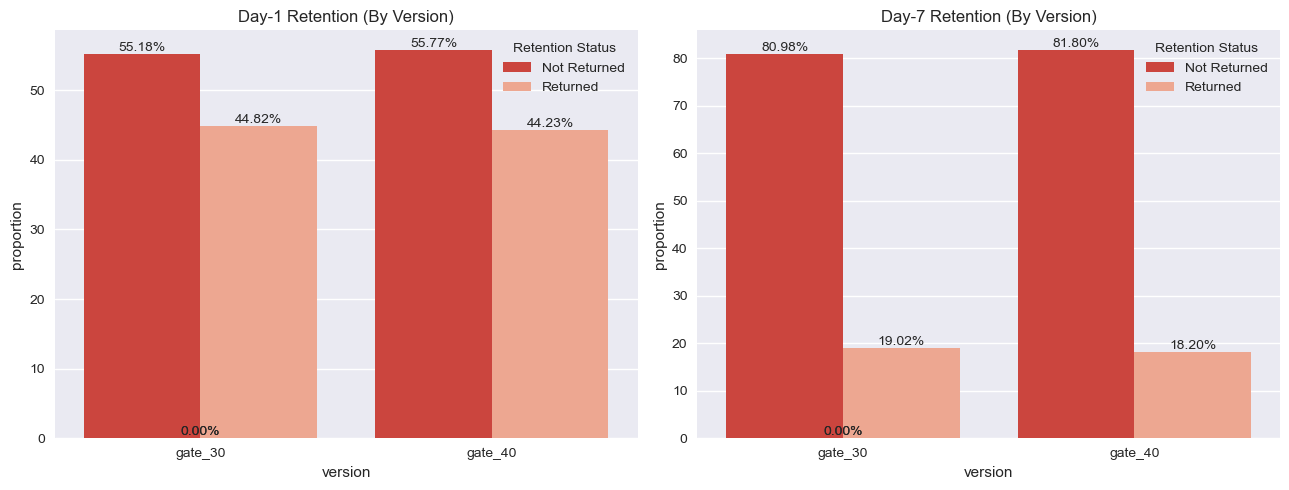

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=ver_ret_1,x='version',y='proportion',hue='retention_1', ax=ax[0],palette='Reds_r')
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.2f}%', 
                   (p.get_x() + p.get_width() / 2, p.get_height()), 
                   ha='center', va='bottom')
handles, labels = ax[0].get_legend_handles_labels()

ax[0].legend(handles=handles, labels=['Not Returned', 'Returned'], title='Retention Status')
ax[0].set_title('Day-1 Retention (By Version)')

sns.barplot(data=ver_ret_7, x='version', y='proportion', hue='retention_7', palette='Reds_r', ax=ax[1])
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.2f}%', 
                   (p.get_x() + p.get_width() / 2, p.get_height()), 
                   ha='center', va='bottom')
handles, labels = ax[1].get_legend_handles_labels()

ax[1].legend(handles=handles, labels=['Not Returned', 'Returned'], title='Retention Status')
ax[1].set_title('Day-7 Retention (By Version)')

plt.tight_layout()
plt.show()

### Retention Distribution across version.

In [60]:
dist_retention_1 = pd.crosstab(df['version'],df['retention_1'],normalize='index')
display(dist_retention_1)

dist_retention_7 = pd.crosstab(df['version'],df['retention_7'],normalize='index')
display(dist_retention_7)

retention_1,False,True
version,,
gate_30,0.551812,0.448188
gate_40,0.557717,0.442283


retention_7,False,True
version,,
gate_30,0.809799,0.190201
gate_40,0.818000,0.182000


### Outlier Detection

In [61]:
control_group = df[df['version'] =='gate_30']
treatment_group = df[df['version']=='gate_40']

In [62]:
def remove_outliers_iqr(df):
    df_stats = df['sum_gamerounds'].describe()
    Q1 = df_stats['25%']
    Q3 = df_stats['75%']
    Q2 = df_stats['50%']
    IQR = Q3 - Q1
    
    min_bound = Q1 - 1.5 * IQR
    max_bound = Q3 + 1.5 * IQR

    temp_df = df[(df['sum_gamerounds']>=min_bound) & (df['sum_gamerounds']<=max_bound)]
    return temp_df

In [63]:
control_group = remove_outliers_iqr(control_group)
treatment_group = remove_outliers_iqr(treatment_group)

### Problem Statement

Cookie Cats is a popular mobile puzzle game. As player progress through the game they encounter a "gate" which force them to wait or to make an in-app purchase to continue. Currently the gate is place at level 30 and the team wants to know if placing the gate to level 40 will improve the user retention without harming the engagement.

#### Setup

* **Control Group:** The group that does not receive the treatment or intervention.
* **Treatment Group:** The group that receives the treatment or intervention.
---
Question 1: Has the average number of game sessions increased by 5 sessions?


**Objective:** To determine if the treatment has increased the average number of game sessions by 5 sessions.

*    **Null Hypothesis (H0):** There is no increase in aaverage number of game session in treatment group and control group.

*    **Alternative Hypothesis (H1):** The average number of game sessions in the treatment group has increased by 5 sessions compared to the control group.

---
Question 2: Has player retention increased by 2% after 1 day?

**Objective:** To determine if the treatment has increased player retention by 2% one day after installation.

*    **Null Hypothesis (H0):** The player retention rate one day after installation in the treatment group has not increased by 2% compared to the control group.

*    **Alternative Hypothesis (H1):** The player retention rate one day after installation in the treatment group has increased by 2% compared to the control group.

---

Question 3: Has player retention increased by 5% after 7 days?
    
**Objective:** To determine if the treatment has increased player retention by 5% seven days after installation.

*    **Null Hypothesis (H0):** The player retention rate seven days after installation in the treatment group has not increased by 5% compared to the control group.

*    **Alternative Hypothesis (H1):** The player retention rate seven days after installation in the treatment group has increased by 5% compared to the control group.
---


Based on standard practice, we will use the following values for our tests:

* Alpha (α): 0.05 (5%)
                 
* Beta (β): 0.20 (20%)
                 
* Power: 0.80 (80%)


In [64]:
alpha = 0.05
beta = 0.20
power = 0.80
z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power)

### Sample Size Estimation (For Continuos A/B test)

$$n = \frac{2 \sigma^2 (Z_{\alpha/2} + Z_{\beta})^2}{\Delta^2}$$




* **$n$ (Sample Size)**: The required number of users or observations needed **per group** (Control vs. Treatment). To get the total sample size for the experiment, multiply this by 2.
* **$\sigma^2$ (Variance)**: The variance of number of game sessions in the current population. 

* **$Z_{\alpha/2}$ (Z-score for Significance Level)**:It defines confidence level. For ($\alpha = 0.05$), this value is **1.96**.
                                                                                                                          
* **$Z_{\beta}$ (Z-score for Statistical Power)**:It represents the probability of correctly detecting an effect if one exists. For  ($\beta = 0.20$), this value is **0.84**.
                                                                                                                                                                                                                                                 
* **$\Delta$ (Minimum Detectable Effect / MDE)**: The absolute difference we want to be able to detect between the two groups. 

In [65]:
def sample_size(std_dev,delta,alpha=0.05,power=0.80):
    z_alpha =stats.norm.ppf(1-alpha/2)
    z_beta = stats.norm.ppf(power)

    n =  2 * ((std_dev**2) * (z_alpha+z_beta)**2)/delta**2

    return n

### Question-1

In [66]:
delta = 5 # if the average number of game sessions has increased by 5

In [67]:
n_control = sample_size(control_group['sum_gamerounds'].std(),delta)
n_treatment = sample_size(treatment_group['sum_gamerounds'].std(),delta)

#### Applying independent two sample t-test

**Assumptions**

* Observations in the sample must be independent of each other.

* For a t-test, we assume that the samples are drawn from a normally distributed population(n>=30).

* The t-test assumes that the variances of the two groups are equal. This can be tested using Levene’s test.
  

In [68]:
sample_control_group = control_group.sample(int(n_control),random_state=42)
sample_treatment_group = treatment_group.sample(int(n_treatment),random_state=42)

In [69]:
mean_control_group = sample_control_group['sum_gamerounds'].mean()
mean_treatment_group = sample_treatment_group['sum_gamerounds'].mean()
std_control = sample_control_group['sum_gamerounds'].std()
std_treatment = sample_treatment_group['sum_gamerounds'].std()

In [70]:
print(f"Mean of the Sample Control Group: {mean_control_group:.4f}")
print(f"Mean of the Sample Treatment Grorup: {mean_treatment_group:.4f}")
print()
print(f"Standard Deviation of the Sample Control Group: {std_control:.4f}")
print(f"Standard Deviation of the Sample Treatment Group: {std_treatment:.4f}")


Mean of the Sample Control Group: 21.3296
Mean of the Sample Treatment Grorup: 25.8755

Standard Deviation of the Sample Control Group: 23.8034
Standard Deviation of the Sample Treatment Group: 28.6266


In [71]:
stat, p_levene = levene(sample_control_group['sum_gamerounds'], sample_treatment_group['sum_gamerounds'])
equal_var = None
# Check if variances are equal
if p_levene < alpha:
    print("Assumption not met: The variances of the two groups are not equal. Switching to Welch's t-test.")
    equal_var = False
else:
    print("Assumption met: The variances of the two groups are equal.")
    equal_var = True


Assumption not met: The variances of the two groups are not equal. Switching to Welch's t-test.


In [72]:
t_score = (mean_treatment_group-mean_control_group)/(np.sqrt((std_control**2/n_control)+(std_treatment**2/n_treatment)))
p_value = stats.t.sf(abs(t_score), n_control+n_treatment-2) 

In [73]:
print(f"T-score: {t_score:.4f}")
print(f"P_value: {p_value:.4f}")

T-score: 2.6598
P_value: 0.0040


In [74]:
if p_value <= alpha:
    print("Reject the Null Hypothesis.\nHence average number of sessions in treatment group has increased by 5 as compared to control group.")
else:
    print("Could Not Reject the Null Hypothesis.")

Reject the Null Hypothesis.
Hence average number of sessions in treatment group has increased by 5 as compared to control group.


### Question-2

### Sample size estimation (For Binary A/B test)
$$n = \left(\frac{Z_{\alpha/2} + Z_{\beta}}{p_1 - p_2}\right)^2 (p_1(1 - p_1) + p_2(1 - p_2))$$


* **$Z_{\alpha/2}$**: The Z-score for the chosen significance level.
* **$Z_{\beta}$**: The Z-score for the chosen power.
* **$p_1$**: The proportion of success in the control group.
* **$p_2$**: The proportion of success in the treatment group.

In [75]:
def calculate_sample_size_binary(p1, p2, Z_alpha, Z_beta):
    pooled_prob = (p1 + p2) / 2
    return int(((Z_alpha * (2 * pooled_prob * (1 - pooled_prob)) ** 0.5 + Z_beta * (p1 * (1 - p1) + p2 * (1 - p2)) ** 0.5) / (p1 - p2)) ** 2)


In [76]:
crosstab_retention_1 = pd.crosstab(df['version'],df['retention_1'],normalize='index')
crosstab_retention_7 = pd.crosstab(df['version'],df['retention_7'],normalize='index')

p1_retention_1 = crosstab_retention_1.loc['gate_30',True]
p1_retention_7 = crosstab_retention_7.loc['gate_30',True]

p2_retention_1 = p1_retention_1 + 0.02 
p2_retention_7 = p1_retention_7 + 0.05


# Calculate sample sizes
n_retention_1 = calculate_sample_size_binary(p1_retention_1, p2_retention_1, z_alpha, z_beta)
n_retention_7 = calculate_sample_size_binary(p1_retention_7, p2_retention_7, z_alpha, z_beta)

In [77]:
sample_control_group_1 = control_group.sample(n=int(n_retention_1),random_state=42)
sample_treatment_group_1 = treatment_group.sample(n=int(n_retention_1),random_state=42)

In [78]:
# This is the absolute number of people who actually did the thing you wanted them to do
n_count_1 = [sample_treatment_group_1['retention_1'].sum(),sample_control_group_1['retention_1'].sum()]
n_nobs_1 = [n_retention_1,n_retention_1]

In [79]:
z_score,p_val_retention_1 = z_stat, p_value = proportions_ztest(
    count=n_count_1, 
    nobs=n_nobs_1,
    value=0.02,
    alternative='larger'
)

In [80]:
print(f"Z-score: {z_score:.4f}")
print(f"p_val: {p_val_retention_1:.4f}")

Z-score: -3.3838
p_val: 0.9996


In [81]:
if p_val_retention_1 < alpha:
        print("Reject the null hypothesis: The retention rate after 1 day has significantly increased.")
else:
        print("Fail to reject the null hypothesis: The retention rate after 1 day has not significantly increased.")

Fail to reject the null hypothesis: The retention rate after 1 day has not significantly increased.


### Question-3

In [82]:
sample_control_group_7 = control_group.sample(n=int(n_retention_7),random_state=42)
sample_treatment_group_7 = treatment_group.sample(n=int(n_retention_7),random_state=42)

In [83]:
n_count_7 = [sample_treatment_group_7['retention_7'].sum(),sample_control_group_7['retention_7'].sum()]
n_nobs_7 = [n_retention_7,n_retention_7]

In [84]:
z_score,p_val_retention_7 = z_stat, p_value = proportions_ztest(
    count=n_count_7, 
    nobs=n_nobs_7,
    value=0.05,
    alternative='larger'
)

In [85]:
print(f"Z-score: {z_score:.4f}")
print(f"p_val: {p_val_retention_7:.4f}")

Z-score: -2.6211
p_val: 0.9956


In [86]:
if p_val_retention_7 < alpha:
        print("Reject the null hypothesis: The retention rate after 1 day has significantly increased.")
else:
        print("Fail to reject the null hypothesis: The retention rate after 1 day has not significantly increased.")

Fail to reject the null hypothesis: The retention rate after 1 day has not significantly increased.


### Summary
* **Game Sessions:** Using an independent two-sample t-test, the results show that moving the gate to level 40 increased the average number of game sessions by roughly 5 per user compared to the baseline level 30 gate.
* **User Retention:** Based on the binary A/B test results, there was no statistically significant difference in either Day 1 or Day 7 retention rates between the two gate placements. 

### Insights
* **Flow State vs. Retention:** Placing the gate at level 40 successfully drives up total user sessions, likely because it delays interruption and lets players stay in their "flow state" longer. However, this increase in early sessions does not actually influence long-term retention.
* **The Core Issue is Gameplay, Not Gates:** The data shows a massive 80% user churn by Day 7 across both groups. This indicates that gate placement is not the primary factor deciding whether a player returns to the app. For players to stick around, the core game needs to strike a better balance between fun and challenging. Right now, the game likely isn't hitting that sweet spot for the majority of users, which is the real root cause behind the 80% drop-off.